The evaluation file (pdf) of interest (~450) are quite various in structure, quality, layout, ... Also the ocr process is far from being perfect in terms of headings preservation (because of variability/quality and also length also up to 150 pages). Currently in the ocr step, I am cleaning a bit the headings via an LLM but still sometimes wrong. For the selection of a subset of section about ~15K tokens from executive summary, intro, conclusions, recommendations, ... it's also somewhat edgy as the TOCs, naming, ... can vary a lot. I did implement a LLM-based method to extract/select those subsections but this is a prominent error mode. 

My idea is to have human in the loop at this step, as a data sanitation step. It's a bit tedious but (i) it will be done once (for all reports) then for  future ones (not those many per year ~ 50 let's say) we will ensure they provide them in a standard/clean way and (ii) it's also a good opportunity to take a close look at our data (this data will be the basis for future analysis also so that's an investment in future I believe also). But to do so, I want to streamline the process through an ad hoc fasthml local/app (as a single module in the current package). Along that line:

    - I could first ocr (+ heading fix). It will download and ocr all the pdfs locally
    - then at this stage, we want human in the loop. We could have another module in this package that:
        - as a fasthtml app., displays:
            - on the left the list of ocrd reports (with different status, cleaned, not cleaned, to be checked or something alike)
            - on the right the headings of the ocrd pdf as each entry editable (to fix it) - should be displayed as "# title ...", "## 2.1 ...", or whatever but then we can easily fix the levels, then on the right a check box to say that we want to use it or not for tagging). Each time we click, we get the total number of tokens selected
        - we could save in the "Report" object the status as well as the selected sections (we can also persist them in the produced .json), ...

What's your opinion on your approach?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Your approach makes a lot of sense. A few thoughts:

**Strengths of your plan:**
- Human-in-the-loop at the heading/section stage is the right place — fixing OCR errors upstream compounds benefits downstream
- One-time investment for ~450 reports is reasonable, especially if it improves all future analysis
- FastHTML is a good fit for this kind of internal tooling — lightweight, Python-native, quick to iterate

**Design considerations:**

1. **Two-phase vs one-phase cleaning**: You mention fixing headings *and* selecting sections. These could be:
   - **Combined**: Fix heading levels inline, checkbox to include/exclude — simpler UI
   - **Separate**: First pass = fix headings only, second pass = select sections — cleaner separation of concerns
   
   Which feels more natural for your workflow?

2. **Heading display**: Showing the actual markdown prefix (`# `, `## `, etc.) is good for editability. You might also want to show a few lines of content under each heading so reviewers can judge relevance.

3. **Status model**: For the Report, you could add something like:
   ```python
   status: str  # 'pending', 'headings_fixed', 'sections_selected', 'verified'
   selected_headings: list[dict]  # [{heading: str, level: int, include: bool, start_line: int, end_line: int}, ...]
   ```

4. **Token budget**: Real-time token count as you toggle sections is a nice UX touch — helps stay within the ~15K target.

What's your preference on the two-phase vs combined approach? That will shape the UI structure.

- You are right for the two stages, it makes sense to separate concern
- no, no need to show text below. Instead, would be nice to have a fast way to show the original pdf we can browse (it could be as simple as a link, or a way to embed the pdf in the app itself (if not too challenging)
- for the status we should have "pending", "headings_reviewed" (it might happen that the headings were actually right so it's semantically more correct), 'sections_selected' (implied we went through all previous steps) and finally "verified" (or something referring to the fact that the report is ready to be tagged)
- for token budget, we have the "n_tokens" function in "00_core.ipynb" module
- for the format on selected headings, you can refer to the "03_extract.ipynb" module. We use "create_heading_dict" from toolslm package to create a nested dictionary of headings as then we can retrieve by keys for instance: 
```
[['Report Title ... page 1', 'Executive Summary ... page 1'],
  ['Report Title ... page 1',
   '1. Introduction ... page 2',
   '1.1 Objectives ... page 2'],
  ['Report Title ... page 1', '3. Conclusions ... page 5'],
  ['Report Title ... page 1', '4. Recommendations ... page 6']]
```

It helps also desambiguate situations where two similar subheadings

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good clarifications. The nested heading path format from `create_heading_dict` is smart — it handles disambiguation naturally.

For the PDF viewing, embedding is straightforward in HTML via `<iframe>` or `<embed>` with a local file URL. FastHTML can serve static files easily. A side-by-side layout (PDF on one side, heading editor on the other) would let reviewers cross-reference without switching tabs.

Quick question on workflow before we sketch the module structure:

**For the headings review stage**, what exactly can the user edit?
- Just the heading **level** (e.g. change `##` to `###`)?
- The heading **text** itself (fix OCR typos)?
- Both?

And should they be able to **delete** spurious headings (e.g. OCR mistakenly promoted a bold line to a heading)?

- for the headings review stage, it will be mainly the heading level
- yes they are also able to delete spurious headings (in such a case, suffices to remove any prepending #)
- last status, selected sections, ... should be saved in the report json file. The current format by the way should be aligned with this one:

```
{
  "id": "760568a15e144bcfb88dbbd50247dc51",
  "report_url": "https://evaluation.iom.int/sites/g/files/tmzbdl151/files/docs/resources/IOM%20LMI%20-%20final%20report%20April%2023.pdf",
  "meta": {
    "Title": "THEMATIC EVALUATION OF IOM'S LABOUR MIGRATION AND MOBILITY STRATEGY AND INITIATIVES",
    ...
  },
  "mappings": {
    "enbs": [
      {
        "theme_id": "2",
        "theme_title": "Partnership",
        "relevance_score": 0.84,
        "reasoning": ...
      },
      ...
    ],
    "ccps": [
      {
        "theme_id": "2",
        "theme_title": "Equality, Diversity & Inclusion",
        "relevance_score": 0.58,
        "reasoning": ...
      }, ...
    ],
    "gcms": [
      {
        "theme_id": "16",
        "theme_title": "Empower Migrants And Societies To Realize Full Inclusion And Social Cohesion",
        "relevance_score": 0.91,
        "reasoning": ...
      },
      ...
    ],
    "outs": [
      {
        "theme_id": "3c51",
        "theme_title": "Governments [at the local, national and regional levels] and key stakeholders have the skills, knowledge, resources and evidence to effectively mainstream migration into relevant multi-sectoral policies and strategies.",
        "relevance_score": 0.82,
        "reasoning": ...
      }, ...
    ],
  "timestamp": "2026-01-16T11:34:21.362345"
}
```

This should form the basis (on top of which we can add attribues required for "Report" objects.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Clear. So the JSON schema would extend to something like:

```python
{
  "id": "...",
  "report_url": "...",
  "meta": {...},
  "status": "pending",  # pending | headings_reviewed | sections_selected | verified
  "pdf_path": "...",
  "md_path": "...",
  "headings": [  # populated after OCR, editable in review
    {"path": ["Report Title", "Executive Summary"], "level": 2, "page": 1},
    {"path": ["Report Title", "1. Introduction"], "level": 2, "page": 2},
    ...
  ],
  "selected_headings": [  # paths of headings selected for extraction
    ["Report Title", "Executive Summary"],
    ["Report Title", "3. Conclusions"],
    ...
  ],
  "sections": "...",  # extracted text from selected_headings
  "mappings": {...},
  "timestamp": "..."
}
```

Does this structure look right? 

If so, shall we start with:
1. Updating the `Report` class to align with this schema, or
2. Sketching the FastHTML app module structure first?

That's a good start. A few remarks though:
- we have access to the ocr markdown at "md_path":
    - we can retrieve at any moment the headings from it right
    - why should we need to store it in the json?
    - for the extracted text, couldn't we instead create/write a "tag_sub.md" file in the same md_path as the full version? And access it/overwrite it as needed? I am a bit afraid of bloating those json files, in particular because later on I am loading them in another app portrarying the tags, ...

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good points — keeping JSON lean is wise.

So the md files become the source of truth for headings. But one question: when the user edits heading levels in the review UI, where should those edits be persisted?

**Option A**: Edit the markdown files directly (e.g. change `### Conclusions` to `## Conclusions` in the actual .md files)

**Option B**: Store level overrides in JSON (original md unchanged, edits applied at read time)

Option A is simpler and keeps everything in one place. Option B preserves the original OCR output if you ever need to compare.

Which do you prefer?

We could indeed keep the original but if it's wrong what's the point? Keeping track of our fixes (not sure that helpful). Option A is simpler and relevant I think

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Agreed. So to summarize the data model:

**Markdown files** (`md_path/`):
- `page_*.md` — OCR output, edited in place for heading fixes
- `tag_sub.md` — extracted sections for tagging (written after selection)

**JSON** (`results_path/{id}.json`):
- `status` — workflow state
- `selected_headings` — list of heading paths to extract
- `mappings` — theme mappings
- `meta`, `report_url`, `pdf_path`, `md_path`, `timestamp`

This keeps JSON light and markdown as the source of truth for content.

Ready to start on the FastHTML module? I can sketch the app structure and we iterate from there.

In [ ]:
!ls

00_core.ipynb	      04_themes.ipynb	 _index_dup1.ipynb  index.ipynb
01_readers.ipynb      05_mapper.ipynb	 _quarto.yml	    nbdev.yml
02_downloaders.ipynb  06_curator.ipynb	 analysis	    sidebar.yml
03_extract.ipynb      07_pipeline.ipynb  files		    styles.css


## Curator App.

In [ ]:
#| export
# | default_exp curator

In [ ]:
#| export
from fasthtml.common import *
from fasthtml.jupyter import *
from monsterui.all import *
from fastcore.script import call_parse
from iomeval.pipeline import Report, load_report
from pathlib import Path
from mistocr.core import read_pgs
from mistocr.refine import apply_hdg_fixes
from starlette.requests import Request
import re

In [ ]:
#| export
app, rt = fast_app(
    title='IOM Curator',
    hdrs=Theme.slate.headers(mode='light', radii='small'),
    live=True
)

### Helper functions

In [ ]:
#| export
def get_reports(base_path:str='files/test') -> list[Report]:
    "Load all reports from results/*.json in base_path"
    results_dir = Path(base_path)/'results'
    return [load_report(p.stem, base_path) for p in results_dir.glob('*.json')]

In [ ]:
#| export
def fmt_status(status): return status.replace('_', ' ').title()

### Components

In [ ]:
#| export
def get_headings(md_path):
    md = read_pgs(md_path)
    return re.findall(r'^#+\s+.*$', md, re.MULTILINE)

In [ ]:
#| export
status_colors = dict(pending='amber', headings_reviewed='blue', sections_selected='purple', verified='green')

In [ ]:
#| export
def ReportCard(r:Report):
    title = r.ev.meta.get('Title', 'Untitled')
    title_short = title[:60] + '...' if len(title) > 60 else title
    year = r.ev.meta.get('Year', 'n/a')
    return Card(
        Div(cls='space-y-1 uk-width-expand')(
            H5(title_short.upper(), title=title, cls="font-bold text-sm"),
            DivFullySpaced(
                DivLAligned(
                    Label(fmt_status(r.curation_status), cls=f'bg-{status_colors[r.curation_status]}-500 text-white'),
                    Small(f"Year: {year}", cls=TextT.muted),
                    Small(f"ID: {r.id[:5]}...", cls=TextT.muted),
                    A("Report", href=r.pdf_url, target='_blank', cls='text-sm'+AT.primary)
                ),
                Button("Curate", hx_get=f'/report/{r.id}', hx_target='#editor', cls='h-8 uk-btn-xs'+ButtonT.primary)
            )
        ),
        cls='mb-1 p-2'
    )

In [ ]:
#| export
def StatusSteps(status):
    steps = ['pending', 'headings_reviewed', 'sections_selected', 'verified']
    labels = ['Clean Headings', 'Select Sections', 'Verified']
    current_idx = steps.index(status)
    
    return Steps(*[
        LiStep(label, cls=StepT.success if i <= current_idx else StepT.neutral)
        for i, label in enumerate(labels)
    ], cls='mb-4 w-full')


    

In [ ]:
#| export
def HeadingsEditor(r:Report):
    headings = get_headings(r.md_path)
    title = r.ev.meta.get('Title', 'Untitled')
    return Div(
        H5(title, cls='font-bold mb-2 text-sm'),
        StatusSteps(r.curation_status),
        Form(
            Div(*[
                Input(value=h, name=f'heading_{i}', cls='mb-1 w-full font-mono text-xs')
                for i, h in enumerate(headings)
            ], 
            cls='space-y-1 max-h-[60vh] overflow-y-auto px-2 py-2 bg-slate-50 rounded border border-slate-200'
            ),
            Hidden(name='report_id', value=r.id),
            DivCentered(Button("Save & Mark Reviewed", type='submit', cls=ButtonT.primary), cls='w-full'),
            hx_post=f'/report/{r.id}/save-headings',
            hx_target='#editor'
        )
    )

In [ ]:
#| export
def SectionsSelector(r:Report):
    headings = get_headings(r.md_path)
    title = r.ev.meta.get('Title', 'Untitled')[:60]
    return Div(
        H5(title, cls='font-bold mb-2 text-sm'),
        StatusSteps(r.curation_status),
        Form(
            Div(
                Table(
                    Tbody(*[
                        Tr(
                            Td(CheckboxX(name=f'hdg_{i}'), cls='w-8 !py-1'),
                            Td(h, cls='font-mono text-xs !py-1'),
                            cls='border-b'
                        )
                        for i, h in enumerate(headings)
                    ]),
                    cls='w-full uk-table-middle'
                ),
                cls='max-h-[60vh] overflow-y-auto bg-slate-50 rounded border border-slate-200'
            ),
            DivCentered(
                DivLAligned(
                    Button("Save Selection", type='submit', cls=ButtonT.primary), 
                    Span("0 tokens", id='token-count', cls='ml-4 text-sm'+TextT.muted)
                ),
                cls='mt-2'),
            hx_post=f'/report/{r.id}/save-sections',
            hx_target='#editor'
        ),
        Button("← Back to Headings", hx_post=f'/report/{r.id}/reset-to-pending', hx_target='#editor', cls='mt-2')
    )

### Routes

In [ ]:
@rt('/')
def get():
    reports = get_reports()
    return Container(
        H2("IOMEVAL | Report Curator", cls="text-2xl font-bold mb-6"),
        Grid(
            Card(H4("Reports"), Div(*[ReportCard(r) for r in reports], cls='overflow-y-auto max-h-[80vh]')),
            Card(H4("Editor"), Div(id='editor', cls='p-2')("Click 'Curate' to select a report"), cls="h-full"),
            cols=2, gap=4
        ),
        cls="p-4"
    )

In [ ]:
@rt('/report/{id}')
def get(id:str):
    r = load_report(id, 'files/test')
    status = r.curation_status
    
    return (
        HeadingsEditor(r) if status == 'pending' else
        SectionsSelector(r) if status == 'headings_reviewed' else
        VerifiedView(r)
    )

In [ ]:
@rt('/report/{id}/save-headings')
async def post(id:str, req:Request):
    form = await req.form()
    r = load_report(id, 'files/test')
    original_headings = get_headings(r.md_path)
    
    # Build lookup table: {original: edited}
    lut_fixes = {}
    for i, orig in enumerate(original_headings):
        edited = form.get(f'heading_{i}', orig)
        if edited != orig: lut_fixes[orig] = edited
    
    print("Lookup table (changes only):")
    for old, new in lut_fixes.items():
        print(f"  '{old}' → '{new}'")
    
    # Apply fixes to each page if there are changes
    if lut_fixes:
        for pg_path in sorted(r.md_path.glob('page_*.md')):
            content = pg_path.read_text()
            fixed = apply_hdg_fixes(content, lut_fixes)
            pg_path.write_text(fixed)
    
    # Update status and save
    r.curation_status = 'headings_reviewed'
    r.save()
    
    # Refresh both panels
    reports = get_reports()
    return (
        Div(*[ReportCard(rp) for rp in reports], id='report-list', hx_swap_oob='true'),
        SectionsSelector(r)  # Next step UI
    )

In [ ]:
@rt('/report/{id}/reset-to-pending')
def post(id:str):
    r = load_report(id, 'files/test')
    r.curation_status = 'pending'
    r.save()
    
    reports = get_reports()
    return (
        Div(*[ReportCard(rp) for rp in reports], id='report-list', hx_swap_oob='true'),
        HeadingsEditor(r)
    )

In [ ]:
@rt('/report/{id}/save-headings')
async def post(id:str, req:Request):
    form = await req.form()
    r = load_report(id, 'files/test')
    original_headings = get_headings(r.md_path)
    
    # Build lookup table: {original: edited}
    lut_fixes = {}
    for i, orig in enumerate(original_headings):
        edited = form.get(f'heading_{i}', orig)
        if edited != orig: lut_fixes[orig] = edited
    
    print("Lookup table (changes only):")
    for old, new in lut_fixes.items():
        print(f"  '{old}' → '{new}'")
    
    # Display in browser
    changes = [Li(f"'{old}' → '{new}'") for old, new in lut_fixes.items()]
    
    return Div(
        H5("Changes to apply:"),
        Ul(*changes) if changes else P("No changes detected"),
    )

In [ ]:
# | export
@call_parse
def main(host:str='0.0.0.0', port:int=5001):
    "Run the curator app"
    serve(host=host, port=port)

if __name__ == "__main__": main()

### Server

In [ ]:
# Dev cell (not exported)
srv = JupyUvi(app)

In [ ]:
srv.stop()

I think we should start by revising the saved json structure. This will be done in the "07_pipeline.ipynb" module.

Currently under `files/test` we have:
- a couple of downloaded pdfs under `pdfs` subdir
- their ocr version under under `md` and `md/49d2...` for each eval (with 49d2... being the eval id)
- the `results` subfolder with individual .json

I think we should start from this.
1. maybe renaming the folders in a consistent way (plural vs singular)
2. review the .json structure

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me look at the current structure:

<details class='tool-usage-details'>
<summary>view(path='files/test')</summary>

```json
{
  "id": "toolu_019mj9hfzPkhhPakAfJnPMAU",
  "call": {
    "function": "view",
    "arguments": {
      "path": "files/test"
    }
  },
  "result": "'Directory contents of /app/data/iomeval/nbs/files/test:\\n/app/data/iomeval/nbs/files/test/evaluation-search-export-11_13_2025--18_09_44.csv (676.3k)\\n/app/data/iomeval/nbs/files/test/eval_reports \ud83d\udcc1\\n/app/data/iomeval/nbs/files/test/evaluation-search-export-01_27_2026--21_43_30.csv (682.9k)\\n/app/data/iomeval/nbs/files/test/pdfs \ud83d\udcc1\\n/app/data/iomeval/nbs/files/test/results \ud83d\udcc1\\n/app/data/iomeval/nbs/files/test/image_cache.json (0.1k)\\n/app/data/iomeval/nbs/files/test/eval_repo_iom.xlsx (16.8k)\\n/app/data/iomeval/nbs/files/test/md \ud83d\udcc1\\n/app/data/iomeval/nbs/files/test/iom_evals_test.json (2127.7k)\\n<TRUNCATED>"
}
```

</details>



<details class='tool-usage-details'>
<summary>view(path='files/test/results/49d2fba781b6a7c0d94577479636ee6…', view_range=[1, 50])</summary>

```json
{
  "id": "toolu_014dL2aFWj2oeym8F8W1Wr3L",
  "call": {
    "function": "view",
    "arguments": {
      "path": "files/test/results/49d2fba781b6a7c0d94577479636ee6f.json",
      "view_range": "[1, 50]"
    }
  },
  "result": "'{\\n  \"id\": \"49d2fba781b6a7c0d94577479636ee6f\",\\n  \"ev_meta\": {\\n    \"Title\": \"Final Evaluation of the EU-IOM Joint Initiative for migrant protection and reintegration in the horn of Africa\",\\n    \"Year\": 2023,\\n    \"Author\": \"PPMI Group\",\\n    \"Best Practicesor Lessons Learnt\": \"Yes\",\\n    \"Date of Publication\": \"2023-03-17\",\\n    \"Donor\": \"European Union\",\\n    \"Evaluation Brief\": \"Yes\",\\n    \"Evaluation Commissioner\": \"IOM\",\\n    \"Evaluation Coverage\": \"Regional\",\\n    \"Evaluation Period From Date\": \"nan\",\\n    \"Evaluation Period To Date\": \"nan\",\\n    \"Executive Summary\": \"Yes\",\\n    \"Exter<TRUNCATED>"
}
```

</details>

Good. Now let me see the rest and check the current 07_pipeline.ipynb to understand the existing structure:

<details class='tool-usage-details'>
<summary>view(path='07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_01PuSQbrWP6iBwpx4X1ihXCu",
  "call": {
    "function": "view",
    "arguments": {
      "path": "07_pipeline.ipynb"
    }
  },
  "result": "'{\\n \"cells\": [\\n  {\\n   \"cell_type\": \"markdown\",\\n   \"id\": \"c1351103\",\\n   \"metadata\": {},\\n   \"source\": [\\n    \"# Pipeline\\\\n\",\\n    \"\\\\n\",\\n    \"> End-to-end pipeline for processing IOM evaluation reports\\\\n\"\\n   ]\\n  },\\n  {\\n   \"cell_type\": \"markdown\",\\n   \"id\": \"b48f6941\",\\n   \"metadata\": {},\\n   \"source\": [\\n    \"The `Report` class orchestrates the full evaluation pipeline:\\\\n\",\\n    \"\\\\n\",\\n    \"1. **Download** - Fetch PDFs from IOM evaluation repository\\\\n\",\\n    \"2. **OCR** - Convert PDFs to markdown with heading hierarchy\\\\n\",\\n    \"3. **Extract** - Pull core sections from converted<TRUNCATED>"
}
```

</details>

Now I have a good picture. Let me summarize what I see:

**Current structure:**
- `files/test/pdfs/{id}/` — downloaded PDFs
- `files/test/md/{id}/` — OCR'd markdown (page_*.md files)
- `files/test/results/{id}.json` — results with mappings

There's some inconsistency:
- `pdfs` (plural) vs `md` (singular)
- There's also an orphan `eval_reports` folder and a stray `AAP%20Evaluation%20Report_final_` folder

**For the JSON**, the current structure in `save()` is:
```python
{id, ev_meta, ev_docs, sections, mappings, pdf_path, md_path, results_path}
```

Based on our earlier discussion, the revised JSON should be:
```python
{
  "id": "...",
  "report_url": "...",
  "meta": {...},  # was ev_meta
  "docs": [...],  # was ev_docs
  "status": "pending",  # NEW: pending | headings_reviewed | sections_selected | verified
  "selected_headings": [],  # NEW: list of heading paths for extraction
  "pdf_path": "...",
  "md_path": "...",
  "mappings": {...},
  "timestamp": "..."
}
```

Note: `sections` is removed since it will live in `tag_sub.md` file.

Would you like me to:
1. Propose the folder renaming first (`md` → `mds` for consistency), or
2. Start with updating the `Report` class and JSON schema in 07_pipeline.ipynb?

- yes let's do the folder renaming
- also note that I'd like to add the "report_url" also under "meta" (it will be a duplicate but doing this for a downstream task - we will remove one of them later)
- for the status: we have currently also processing status appearing through the `_repr_markdown_` method of the "Report" class. They are computed on the fly just for display purpose (and infered from the presence or absence of particular Report instance attribute - paths, ...-). Shouldn't we take care of those different status along with the new one we plan to have?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good point about the status. Let me check the current `_repr_markdown_` to see how existing statuses are computed:

<details class='tool-usage-details'>
<summary>rg(argstr='_repr_markdown_ -A 30 07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_01PYYSGvMwKo8jiDy6FmoLUm",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "_repr_markdown_ -A 30 07_pipeline.ipynb"
    }
  },
  "result": "'226:    \"def _repr_markdown_(self:Report) -> str: # Markdown formatted report summary\\\\n\",\\n227-    \"    \\\\\"Display report metadata and processing status in Jupyter notebooks\\\\\"\\\\n\",\\n228-    \"    title = self.ev.meta.get(\\'Title\\', \\'Untitled\\')\\\\n\",\\n229-    \"    year = self.ev.meta.get(\\'Year\\', \\'n/a\\')\\\\n\",\\n230-    \"    org = self.ev.meta.get(\\'Evaluation Commissioner\\', \\'Unknown\\')\\\\n\",\\n231-    \"    \\\\n\",\\n232-    \"    status = []\\\\n\",\\n233-    \"    if self.pdf_path: status.append(f\\'\u2713 PDF downloaded\\')\\\\n\",\\n234-    \"    if self.md_path: status.append(f\\'\u2713 Markdown converted\\')\\\\n\",<TRUNCATED>"
}
```

</details>

So the existing statuses are **pipeline processing statuses** (inferred from data presence):
- PDF downloaded → `pdf_path` exists
- Markdown converted → `md_path` exists  
- Sections extracted → `sections` exists
- Mappings done → `mappings` exists

The new statuses we discussed are **curation/review statuses**:
- `pending` → needs human review
- `headings_reviewed` → headings fixed
- `sections_selected` → sections chosen for tagging
- `verified` → ready for tagging

These are orthogonal — one is about automated processing, the other is about human QA. I'd suggest:

1. Keep the inferred pipeline status in `_repr_markdown_` (computed on the fly)
2. Add a **new field** `curation_status` (persisted in JSON) for the human review workflow

This way they don't conflict. The display could show both, e.g.:
```
**Pipeline:** ✓ PDF | ✓ MD | ✓ Sections
**Curation:** headings_reviewed
```

Does that separation make sense?

Yes indeed

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good. So the plan:

1. **Folder renaming**: `md` → `mds` (to match `pdfs`, `results`)
2. **JSON updates**:
   - Add `report_url` inside `meta` (duplicate for downstream)
   - Add `curation_status` field (default: `"pending"`)
   - Remove `sections` from JSON (will be in `tag_sub.md`)

Let me find where the folder paths are defined in the codebase:

<details class='tool-usage-details'>
<summary>rg(argstr='"md_path|/md" 07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_01RrtPfv2FfzrPeVSH46zCmw",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "\"md_path|/md\" 07_pipeline.ipynb"
    }
  },
  "result": "'125:    \"        self.pdf_path,self.md_path,self.sections,self.mappings = None,None,None,{}\\\\n\",\\n147:    \"        if data.get(\\'md_path\\'): self.md_path = Path(data[\\'md_path\\'])\"\\n234:    \"    if self.md_path: status.append(f\\'\u2713 Markdown converted\\')\\\\n\",\\n436:    \"                pdf_path=str(self.pdf_path) if self.pdf_path else None, md_path=str(self.md_path) if self.md_path else None,\\\\n\",\\n461:    \"    if data.get(\\'md_path\\'): report.md_path = Path(data[\\'md_path\\'])\\\\n\",\\n612:    \"              dst:str=\\'data/md\\',       # Destination directory for markdown files\\\\n\",\\n618:    \"    if<TRUNCATED>"
}
```

</details>

I see `md` is used in several places as default. Should I:

1. Update all occurrences in `07_pipeline.ipynb` (`data/md` → `data/mds`, `files/test/md` → `files/test/mds`)
2. Physically rename the existing `files/test/md` folder

Shall I proceed with both?

Or shouldn't I make them all singular (for the sake of simplicity?)

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good point — singular is simpler and cleaner to type:

- `pdf/` 
- `md/` 
- `result/`

Or keep `results` plural since it contains multiple result files? (whereas `pdf/{id}/` and `md/{id}/` each contain files for one report)

What's your preference?

Ok I renamed pdfs to pdf, kept md and results

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Got it. Let me find the `pdfs` references to update:

<details class='tool-usage-details'>
<summary>rg(argstr='pdfs 07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_01KBWwccF5RTE5G4TiLactbg",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "pdfs 07_pipeline.ipynb"
    }
  },
  "result": "'34:    \"    - I could first ocr (+ heading fix). It will download and ocr all the pdfs\\\\n\",\\n541:    \"             dst:str=\\'data/pdfs\\',  # Destination directory for PDFs\\\\n\",\\n563:    \"_ = report.download(dst=\\'files/test/pdfs\\')\"\\n577:       \"[Path(\\'files/test/pdfs/49d2fba781b6a7c0d94577479636ee6f/Abridged%20Evaluation%20Report_%20Final_Olta%20NDOJA.pdf\\'), Path(\\'files/test/pdfs/49d2fba781b6a7c0d94577479636ee6f/Final%20Evaluation%20Report%20Final_Olta%20NDOJA.pdf\\'), Path(<TRUNCATED>"
}
```

</details>

I'll update the defaults and examples from `pdfs` to `pdf`:

<details class='tool-usage-details'>
<summary>rg(argstr='-n "data/pdfs|test/pdfs" 07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_018k1vbkdUjNw7rcPn8axkxG",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"data/pdfs|test/pdfs\" 07_pipeline.ipynb"
    }
  },
  "result": "'541:    \"             dst:str=\\'data/pdfs\\',  # Destination directory for PDFs\\\\n\",\\n563:    \"_ = report.download(dst=\\'files/test/pdfs\\')\"\\n577:       \"[Path(\\'files/test/pdfs/49d2fba781b6a7c0d94577479636ee6f/Abridged%20Evaluation%20Report_%20Final_Olta%20NDOJA.pdf\\'), Path(\\'files/test/pdfs/49d2fba781b6a7c0d94577479636ee6f/Final%20Evaluation%20Report%20Final_Olta%20NDOJA.pdf\\'), Path(\\'files/test/pdfs/49d2fba781b6a7c0d94577479636ee6f/HoA%20EU%20JI%20Final%20Eval%20-%20Management%20Response%20Matrix%20-%20Final.pdf\\'), Path(<TRUNCATED>"
}
```

</details>



<details class='tool-usage-details'>
<summary>strs_replace(path='07_pipeline.ipynb', old_strs=['data/pdfs', 'files/test/pdfs'], new_strs=['data/pdf', 'files/test/pdf'])</summary>

```json
{
  "id": "toolu_012t4mbQcCXb7K29d1ePkmRu",
  "call": {
    "function": "strs_replace",
    "arguments": {
      "path": "07_pipeline.ipynb",
      "old_strs": "['data/pdfs', 'files/test/pdfs']",
      "new_strs": "['data/pdf', 'files/test/pdf']"
    }
  },
  "result": "'Results for each replacement:\\nError: Multiple matches found (2) of \"data/pdfs\"; Error: Multiple matches found (10) of \"files/tes\u2026\"'"
}
```

</details>



<details class='tool-usage-details'>
<summary>sed(argstr="-i 's|data/pdfs|data/pdf|g; s|files/test/pdfs|file…")</summary>

```json
{
  "id": "toolu_01URUDyqQQ2hu7wyAGgS3VJV",
  "call": {
    "function": "sed",
    "arguments": {
      "argstr": "-i 's|data/pdfs|data/pdf|g; s|files/test/pdfs|files/test/pdf|g' 07_pipeline.ipynb"
    }
  },
  "result": "''"
}
```

</details>

Done. Now for the JSON structure updates — shall I proceed with:

1. Adding `curation_status` field (default: `"pending"`)
2. Adding `report_url` inside `meta`
3. Removing `sections` from saved JSON

ok done, let's tackle the json structure updates now

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠

Let me find the `save` method to see the current JSON structure:

<details class='tool-usage-details'>
<summary>rg(argstr='-n "def save" -A 20 07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_01LfGM7zYUwKWiDvYope991i",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"def save\" -A 20 07_pipeline.ipynb"
    }
  },
  "result": "'429:    \"def save(self:Report,\\\\n\",\\n430-    \"         path:str=None  # Override default results path\\\\n\",\\n431-    \"        ) -> Report:    # Reports self for method chaining\\\\n\",\\n432-    \"    \\\\\"Save report state to JSON\\\\\"\\\\n\",\\n433-    \"    p = Path(path or self.results_path)/f\\'{self.id}.json\\'\\\\n\",\\n434-    \"    p.parent.mkdir(parents=True, exist_ok=True)\\\\n\",\\n435-    \"    data = dict(id=self.id, ev_meta=self.ev.meta, ev_docs=self.ev.docs, sections=self.sections, mappings=self.mappings,\\\\n\",\\n436-    \"                pdf_path=str(self.pdf_path) if self.pdf_path else None, md_path=str(<TRUNCATED>"
}
```

</details>

Current `save` writes:
```python
dict(id, ev_meta, ev_docs, sections, mappings, pdf_path, md_path, results_path)
```

Changes needed:
1. Add `report_url` to `ev_meta` (or rename `ev_meta` to `meta`?)
2. Add `curation_status` (default `"pending"`)
3. Remove `sections`
4. Add `selected_headings` (default `[]`)

Quick question: should we rename `ev_meta` → `meta` and `ev_docs` → `docs` for cleaner naming, or keep them as-is to avoid breaking existing JSON files?

For the renaming we have to comply with this structure:
```
{
  "id": "760568a15e144bcfb88dbbd50247dc51",
  "report_url": "https://evaluation.iom.int/sites/g/files/tmzbdl151/files/docs/resources/IOM%20LMI%20-%20final%20report%20April%2023.pdf",
  "meta": {
    "Title": "THEMATIC EVALUATION OF IOM'S LABOUR MIGRATION AND MOBILITY STRATEGY AND INITIATIVES",
    ...
  },
  "mappings": {
    "enbs": [
      {
        "theme_id": "2",
        "theme_title": "Partnership",
        "relevance_score": 0.84,
        "reasoning": ...
      },
      ...
    ],
    "ccps": [
      {
        "theme_id": "2",
        "theme_title": "Equality, Diversity & Inclusion",
        "relevance_score": 0.58,
        "reasoning": ...
      }, ...
    ],
    "gcms": [
      {
        "theme_id": "16",
        "theme_title": "Empower Migrants And Societies To Realize Full Inclusion And Social Cohesion",
        "relevance_score": 0.91,
        "reasoning": ...
      },
      ...
    ],
    "outs": [
      {
        "theme_id": "3c51",
        "theme_title": "Governments [at the local, national and regional levels] and key stakeholders have the skills, knowledge, resources and evidence to effectively mainstream migration into relevant multi-sectoral policies and strategies.",
        "relevance_score": 0.82,
        "reasoning": ...
      }, ...
    ],
  "timestamp": "2026-01-16T11:34:21.362345"
}
```

+ additional attributes discussed

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Got it. So the target structure is:

```python
{
  "id": "...",
  "report_url": "...",
  "meta": {..., "report_url": "..."},  # report_url duplicated inside
  "curation_status": "pending",
  "selected_headings": [],
  "mappings": {...},
  "timestamp": "..."
}
```

Two questions:
1. What about `ev_docs` — should it stay (as `docs`) or be removed?
2. Should `pdf_path`, `md_path`, `results_path` still be stored, or should these be inferred from conventions (e.g. `md/{id}/`, `pdf/{id}/`)?

- not sure we need the "ev_docs" attribute as it's not used for the current downstream task. Nevertheless, it's not a lot of data anyway, so let's keep this info but indeed rename the attribute "docs"
- About the pdf_path, md_path and results_path, let's think about it. Now for instance, they are essentially a kind of serialized version of a "Report" instance (look for instance one pdf_path = 'files/test/pdfs/49d2fba781b6a7c0d94577479636ee6f'). They help to get the processing status by their presence or not, but above all to "restore" an object from its latest state. But storing it in a json is a bit clumsy as this is a relative path. It this json gets moved, ... it becomes unusable for restoring a "Report" state right?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Exactly. Storing relative paths couples the JSON to its location.

**Alternative**: Infer paths from convention at load time. If you have `base_path` and `id`, then:
- `pdf_path` → `{base_path}/pdf/{id}/`
- `md_path` → `{base_path}/md/{id}/`
- Results live at `{base_path}/results/{id}.json`

The `load` method would take `base_path` as argument and reconstruct paths. Presence/absence of directories determines processing status (as it does now).

This way the JSON is portable — you can move the whole `files/test/` folder anywhere and it still works.

Does that approach work for you?

Yeah makes sense

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good. So the final JSON structure:

```python
{
  "id": "...",
  "report_url": "...",
  "meta": {..., "report_url": "..."},
  "docs": [...],
  "curation_status": "pending",
  "selected_headings": [],
  "mappings": {...},
  "timestamp": "..."
}
```

And paths inferred at load time from `base_path` + `id`.

Let me look at both `save` and `load` methods to update them:

<details class='tool-usage-details'>
<summary>rg(argstr='-n "def load" -A 15 07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_0195onztgPDAWJzdQQ8Kv45Y",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"def load\" -A 15 07_pipeline.ipynb"
    }
  },
  "result": "'464:    \"def load_report(id:str,                  # Report ID (hash)\\\\n\",\\n465-    \"                path:str=\\'data/results\\'  # Results directory\\\\n\",\\n466-    \"               ) -> Report:              # The loaded Report\\\\n\",\\n467-    \"    \\\\\"Load a saved Report by id\\\\\"\\\\n\",\\n468-    \"    data = json.loads((Path(path)/f\\'{id}.json\\').read_text())\\\\n\",\\n469-    \"    ev = Evaluation(id=data[\\'id\\'], meta=data[\\'ev_meta\\'], docs=data[\\'ev_docs\\'])\\\\n\",\\n470-    \"    report = Report(ev, results_path=data.get(\\'results_path\\', path))\\\\n\",\\n471-    \"    report.sections,report.mappings = data[\\'s<TRUNCATED>"
}
```

</details>

Now I have the full picture. Shall I update both `save` and `load_report` now, or would you prefer to review the changes one method at a time?

I prefer to go through the update on my side upon you guidance

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let's start with the `save` method. Currently at line ~429-436, it looks like:

```python
data = dict(id=self.id, ev_meta=self.ev.meta, ev_docs=self.ev.docs, sections=self.sections, mappings=self.mappings,
            pdf_path=str(self.pdf_path) if self.pdf_path else None, md_path=str(self.md_path) if self.md_path else None,
            results_path=str(self.results_path))
```

Changes needed:

1. `ev_meta` → `meta`
2. `ev_docs` → `docs`
3. Add `report_url` at top level (from `self.ev.url` or similar — where does the URL live currently?)
4. Add `report_url` inside `meta` as well
5. Add `curation_status` (you'll need a new attribute on Report, defaulting to `"pending"`)
6. Add `selected_headings` (new attribute, default `[]`)
7. Add `timestamp`
8. Remove `sections`, `pdf_path`, `md_path`, `results_path`

First question: where is the report URL currently stored on the `Report` or `Evaluation` object? Let me check:

<details class='tool-usage-details'>
<summary>rg(argstr='-n "report_url|\.url" 07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_01JM4irGKPZVuVfNFBfV9Vdv",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"report_url|\\.url\" 07_pipeline.ipynb"
    }
  },
  "result": "''"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='-n "URL|url" 07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_01BN4vpi9Bf7rD7WbVvSL8sg",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"URL|url\" 07_pipeline.ipynb"
    }
  },
  "result": "'67:    \"from iomeval.readers import load_evals, find_eval, Evaluation, eval_url\\\\n\",\\n120:    \"        pdf_url:str=None,                # Optional direct URL to PDF\\\\n\",\\n123:    \"        store_attr(\\'ev,pdf_url,results_path\\')\\\\n\",\\n161:    \"def from_url(\\\\n\",\\n163:    \"    url:str,                         # URL of the evaluation PDF\\\\n\",\\n166:    \"    ):                               # Report initialized from URL\\\\n\",\\n167:    \"    \\\\\"Create a Report by finding an evaluation matching the given URL\\\\\"\\\\n\",\\n168:    \"    return cls(find_eval(evals, url, by=\\'url\\'), pdf_url=url, results_path=<TRUNCATED>"
}
```

</details>

Good — the URL is stored as `self.pdf_url`. So you can use that.

Go ahead and update the `save` method with those changes. Let me know when you're done or if you hit any questions!

Can you show me the revised `data` dict?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠

```python
data = dict(
    id=self.id,
    report_url=self.pdf_url,
    meta={**self.ev.meta, 'report_url': self.pdf_url},
    docs=self.ev.docs,
    curation_status=self.curation_status,
    selected_headings=self.selected_headings,
    mappings=self.mappings,
    timestamp=datetime.now().isoformat()
)
```

You'll also need to initialize the two new attributes in `__init__`:
```python
self.curation_status = 'pending'
self.selected_headings = []
```

Ok updated!

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Now let's update `load_report`. Currently it:
1. Reads `ev_meta`, `ev_docs` → need to change to `meta`, `docs`
2. Restores `pdf_path`, `md_path` from JSON → need to infer from `base_path` instead
3. Doesn't handle `curation_status` or `selected_headings`

The signature should change from:
```python
def load_report(id:str, path:str='data/results') -> Report:
```

to:
```python
def load_report(id:str, base_path:str='data') -> Report:
```

And internally infer:
- `results_path` → `{base_path}/results`
- `pdf_path` → `{base_path}/pdf/{id}` (if exists)
- `md_path` → `{base_path}/md/{id}` (if exists)

Ready to see the revised `load_report`?

Yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
def load_report(id:str,                  # Report ID (hash)
                base_path:str='data'     # Base directory containing pdf/, md/, results/
               ) -> Report:              # The loaded Report
    "Load a saved Report by id"
    results_path = Path(base_path)/'results'
    data = json.loads((results_path/f'{id}.json').read_text())
    
    ev = Evaluation(id=data['id'], meta=data['meta'], docs=data['docs'])
    report = Report(ev, pdf_url=data.get('report_url'), results_path=results_path)
    
    # Infer paths from convention
    pdf_dir = Path(base_path)/'pdf'/id
    md_dir = Path(base_path)/'md'/id
    report.pdf_path = pdf_dir if pdf_dir.exists() else None
    report.md_path = md_dir if md_dir.exists() else None
    
    # Restore new attributes
    report.curation_status = data.get('curation_status', 'pending')
    report.selected_headings = data.get('selected_headings', [])
    report.mappings = data.get('mappings', {})
    
    return report
```

Great, what's missing now?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

For the JSON/Report structure, I think we've covered the main pieces:
- ✅ `save` — new structure
- ✅ `load_report` — infer paths, load new attributes
- ✅ `__init__` — new attributes (you mentioned you added these)

Remaining items:

1. **`_repr_markdown_`** — should it display `curation_status` alongside the pipeline status?

2. **`sections` attribute** — we removed it from JSON (will live in `tag_sub.md`), but is it still computed and used on the Report object? If so, should `load_report` read from `tag_sub.md` if it exists?

3. **Existing JSON files** — the ones in `files/test/results/` have the old format. Do you want to migrate them or leave them for now?

Which would you like to tackle next?

- yes would be good to display the "curation_status" also. By the way shouldn't we update the way we retrieve the processing status?
- I think that `tag_sub.md` is the output of a Report + selected headings, not sure we need to store anything at this stage
- I think I will regenerate them from scratch

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good plan on regenerating from scratch.

For the processing status — currently it checks:
- `self.pdf_path` → PDF downloaded
- `self.md_path` → Markdown converted
- `self.sections` → Sections extracted
- `self.mappings` → Mappings done

Since paths are now inferred at load time (and `sections` is removed), are you thinking:
- Keep inferring from path existence (works as before)
- But remove the "Sections extracted" check since `sections` is gone?

Or did you have something else in mind?

- Ah you are right, we are infering those paths during report reload so we can keep the current process in the _repr_markdown_. 
- for the sections extracted, we could also add a new "Report" attribute with the path of the "tag_sub.md", or we could just check the existence of such file under `md/report_id/tag_sub.md`
- also we need to display the curation status right?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Right. For the sections check, I'd lean toward just checking file existence (`self.md_path/'tag_sub.md'` exists) rather than adding another attribute — keeps it simple and consistent with how we're handling paths now.

For displaying curation status in `_repr_markdown_`, you'd add something like:

```python
status.append(f'📋 Curation: {self.curation_status}')
```

Does that work for you?

Can you also provide the update for the check of the existence of tag_sub.md?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Currently it's probably something like:
```python
if self.sections: status.append('✓ Sections extracted')
```

Change it to:
```python
if self.md_path and (self.md_path/'tag_sub.md').exists(): status.append('✓ Sections extracted')
```

Ok please, provide the full update of the `_repr_markdown_` with an appropriate way to portray all those info as markdown (don't change everything just improve)

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me see the current full `_repr_markdown_`:

<details class='tool-usage-details'>
<summary>rg(argstr='-n "_repr_markdown_" -A 20 07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_01HVHpqYf1XNrUsYNFkAT53m",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"_repr_markdown_\" -A 20 07_pipeline.ipynb"
    }
  },
  "result": "'228:    \"def _repr_markdown_(self:Report) -> str: # Markdown formatted report summary\\\\n\",\\n229-    \"    \\\\\"Display report metadata and processing status in Jupyter notebooks\\\\\"\\\\n\",\\n230-    \"    title = self.ev.meta.get(\\'Title\\', \\'Untitled\\')\\\\n\",\\n231-    \"    year = self.ev.meta.get(\\'Year\\', \\'n/a\\')\\\\n\",\\n232-    \"    org = self.ev.meta.get(\\'Evaluation Commissioner\\', \\'Unknown\\')\\\\n\",\\n233-    \"    \\\\n\",\\n234-    \"    status = []\\\\n\",\\n235-    \"    if self.pdf_path: status.append(f\\'\u2713 PDF downloaded\\')\\\\n\",\\n236-    \"    if self.md_path: status.append(f\\'\u2713 Markdown converted\\')\\\\n\",<TRUNCATED>"
}
```

</details>



<details class='tool-usage-details'>
<summary>rg(argstr='-n "_repr_markdown_" -A 30 07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_01LXr9iBtGqptEcKNytZmN3Z",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"_repr_markdown_\" -A 30 07_pipeline.ipynb"
    }
  },
  "result": "'228:    \"def _repr_markdown_(self:Report) -> str: # Markdown formatted report summary\\\\n\",\\n229-    \"    \\\\\"Display report metadata and processing status in Jupyter notebooks\\\\\"\\\\n\",\\n230-    \"    title = self.ev.meta.get(\\'Title\\', \\'Untitled\\')\\\\n\",\\n231-    \"    year = self.ev.meta.get(\\'Year\\', \\'n/a\\')\\\\n\",\\n232-    \"    org = self.ev.meta.get(\\'Evaluation Commissioner\\', \\'Unknown\\')\\\\n\",\\n233-    \"    \\\\n\",\\n234-    \"    status = []\\\\n\",\\n235-    \"    if self.pdf_path: status.append(f\\'\u2713 PDF downloaded\\')\\\\n\",\\n236-    \"    if self.md_path: status.append(f\\'\u2713 Markdown converted\\')\\\\n\",<TRUNCATED>"
}
```

</details>

Here's the updated version:

```python
def _repr_markdown_(self:Report) -> str: # Markdown formatted report summary
    "Display report metadata and processing status in Jupyter notebooks"
    title = self.ev.meta.get('Title', 'Untitled')
    year = self.ev.meta.get('Year', 'n/a')
    org = self.ev.meta.get('Evaluation Commissioner', 'Unknown')
    
    # Pipeline status
    pipeline = []
    if self.pdf_path: pipeline.append('✓ PDF')
    if self.md_path: pipeline.append('✓ MD')
    if self.md_path and (self.md_path/'tag_sub.md').exists(): pipeline.append('✓ Sections')
    if self.mappings:
        mapped = ', '.join(self.mappings.keys())
        pipeline.append(f'✓ Mappings ({mapped})')
    pipeline_str = ' | '.join(pipeline) if pipeline else 'Not processed'
    
    return f"""
## Report: {title}
**Year:** {year} | **Organization:** {org}  
**ID:** `{self.id}`

**Pipeline:** {pipeline_str}  
**Curation:** {self.curation_status}

**Report:** [View Evaluation Report]({self.pdf_url})
"""
```

In [ ]:
!ls files/test

AAP%20Evaluation%20Report_final_		   image_cache.json
eval_repo_iom.xlsx				   iom_evals_test.json
eval_reports					   md
evaluation-search-export-01_27_2026--21_43_30.csv  pdf
evaluation-search-export-11_13_2025--18_09_44.csv  results
evaluations.json


Perfect! The next step is to produce a new clean version of the results json for the two reports we have already

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let me check the existing reports:

<details class='tool-usage-details'>
<summary>view(path='files/test/results')</summary>

```json
{
  "id": "toolu_01FbXfDSUAkZuGCbiEWS5RCi",
  "call": {
    "function": "view",
    "arguments": {
      "path": "files/test/results"
    }
  },
  "result": "'Directory contents of /app/data/iomeval/nbs/files/test/results:\\n/app/data/iomeval/nbs/files/test/results/49d2fba781b6a7c0d94577479636ee6f.json (98.4k)\\n/app/data/iomeval/nbs/files/test/results/6c3c2cf3fa479112967612b0baddab72.json (92.7k)'"
}
```

</details>

Two reports. To regenerate with the new structure, you'll need to:

1. Load the original evaluation data (from `evals` or the existing JSON)
2. Create a fresh `Report` with the new `__init__`
3. Re-attach any existing data (like `mappings`) you want to keep
4. Call `save()`

Do you want to preserve the existing `mappings` from the old JSONs, or start completely fresh?

No I don't need the existing mappings

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good, that simplifies things. You'll need to:

1. Load your evaluations (from CSV or `evaluations.json`)
2. Find the two evals by their IDs
3. Create `Report` objects and `save()` them

Do you have the evals already loaded in your notebook, or should we start from loading them?

Clear. Can we check what's doing the `_load_existing` method currently? Any update needed?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠



<details class='tool-usage-details'>
<summary>rg(argstr='-n "_load_existing" -A 15 07_pipeline.ipynb')</summary>

```json
{
  "id": "toolu_019NhxYALL8xAyzcfhw3Mmi4",
  "call": {
    "function": "rg",
    "arguments": {
      "argstr": "-n \"_load_existing\" -A 15 07_pipeline.ipynb"
    }
  },
  "result": "'112:    \"        self._load_existing()\"\\n113-   ]\\n114-  },\\n115-  {\\n116-   \"cell_type\": \"code\",\\n117-   \"execution_count\": null,\\n118-   \"id\": \"6e1a2613\",\\n119-   \"metadata\": {\\n120-    \"time_run\": \"2026-01-30T11:10:52.268693+00:00\"\\n121-   },\\n122-   \"outputs\": [],\\n123-   \"source\": [\\n124-    \"#| export\\\\n\",\\n125-    \"@patch\\\\n\",\\n126:    \"def _load_existing(self:Report):\\\\n\",\\n127-    \"        \\\\\"Load state from saved JSON if it exists\\\\\"\\\\n\",\\n128-    \"        p = Path(self.results_path)/f\\'{self.id}.json\\'\\\\n\",\\n129-    \"        if not p.exists(): return\\\\n\",\\n130-    \"        data = j<TRUNCATED>"
}
```

</details>

Yes, needs updating. Currently it:
- Loads `sections` (removed)
- Loads `pdf_path`, `md_path` from JSON (now inferred)

Updated version:

```python
@patch
def _load_existing(self:Report):
    "Load state from saved JSON if it exists"
    p = Path(self.results_path)/f'{self.id}.json'
    if not p.exists(): return
    data = json.loads(p.read_text())
    self.mappings = data.get('mappings', {})
    self.curation_status = data.get('curation_status', 'pending')
    self.selected_headings = data.get('selected_headings', [])
```

Paths are inferred elsewhere (in `__init__` or on-demand), not loaded from JSON.

Done! So I think we are ok with our first phase: we have now clean new json results, ... Our next steps are:
1. to use those json to load the list of evaluations for which we have an ocr version (under md/)
2. Show them as a list more or less as we are currently displaying them in 

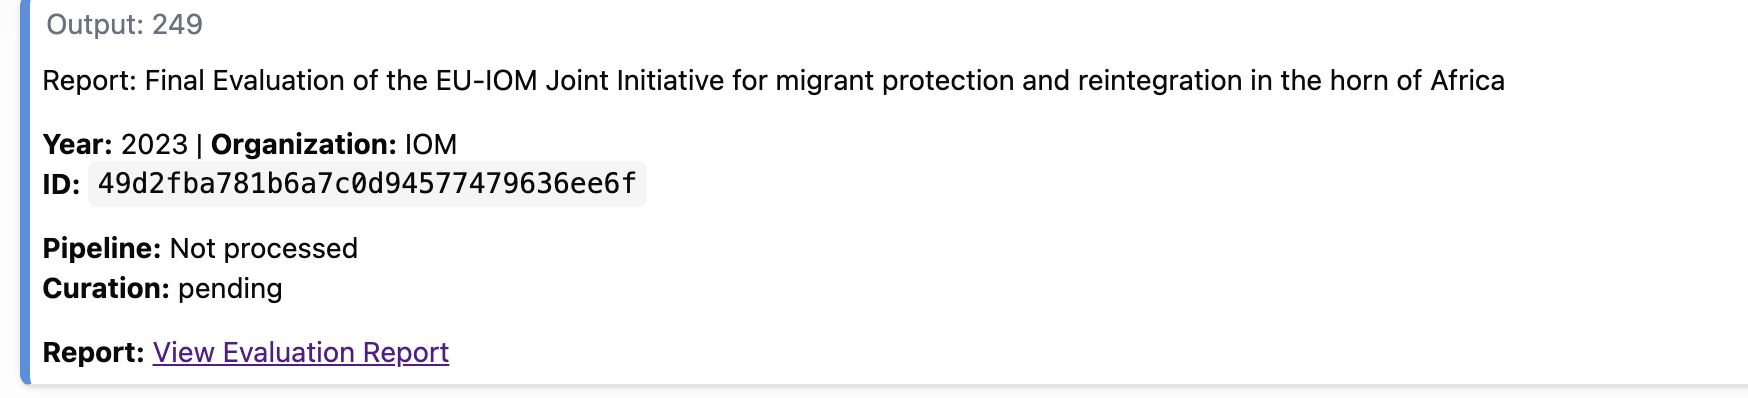

3. then for each of them upon click ("Curate" or something alike), we display, on the right, two tabs (clean headings, select headings - or something alike):
    - the current headings of the ocr, each of them in an editable input, maybe with a button to persist the changes
    - the list of headings a checkbox on the right to include or not ? + button to confirm

We could persist the changes directly on those json, and/or the ocr markdown of corresponding eval report.

At a first glance

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good summary! One design question before we dive in:

**Tabs vs Sequential?**

- **Tabs**: Both "Clean Headings" and "Select Headings" always accessible
- **Sequential**: "Select Headings" tab only enabled/visible after `curation_status == 'headings_reviewed'`

Sequential enforces the workflow but tabs give flexibility. Which do you prefer?

Yes sequential is better, we could use monsterui: https://monsterui.answer.ai/api_ref/docs_steps

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠



<details class='tool-usage-details'>
<summary>read_url(url='https://monsterui.answer.ai/api_ref/docs_steps')</summary>

```json
{
  "id": "toolu_01KsbDky7Q7uiEMFKXBE7ZjE",
  "call": {
    "function": "read_url",
    "arguments": {
      "url": "https://monsterui.answer.ai/api_ref/docs_steps"
    }
  },
  "result": "'* Getting Started\\n    * Getting Started\\n    * Tutorial App\\n  * API Reference\\n    * Accordion | Link\\n    * Button | Link\\n    * Cards\\n    * Charts\\n    * Containers\\n    * Dividers\\n    * Forms\\n    * Html\\n    * Icons | Images\\n    * Layout\\n    * Lightbox\\n    * Lists\\n    * Loading\\n    * Markdown\\n    * Modals\\n    * Navigation\\n    * Notifications\\n    * Sliders\\n    * Steps\\n    * Tables\\n    * Theme | Headers\\n    * Typography\\n  * Guides\\n    * Spacing\\n    * Layout\\n  * Examples\\n    * Task\\n    * Card\\n    * Dashboard\\n    * Form\\n    * Music\\n    * Auth\\n    * Playground\\n    <TRUNCATED>"
}
```

</details>

Nice! The Steps component looks perfect. So for each report, the workflow would show:

```python
Steps(
    LiStep("Clean Headings", cls=StepT.success if status >= 'headings_reviewed' else StepT.primary if status == 'pending' else StepT.neutral),
    LiStep("Select Sections", cls=StepT.success if status >= 'sections_selected' else StepT.primary if status == 'headings_reviewed' else StepT.neutral),
    LiStep("Verified", cls=StepT.success if status == 'verified' else StepT.neutral),
)
```

Shall we start building the left panel (report list) first, then tackle the right panel (steps + editors)?

Yes let's start the left panel first

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

First question: how do you want to load the reports?

Option A: Scan `results/*.json` and load each with `load_report()`

Option B: Pass a `base_path` to the app and it discovers reports automatically

For a simple start, I'd suggest A — a helper function that returns a list of `Report` objects from a directory. Something like:

```python
def get_reports(base_path='files/test') -> list[Report]:
    ...
```

Want to add this to the curator module?

Yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
# | export
def get_reports(base_path:str='files/test') -> list[Report]:
    "Load all reports from results/*.json in base_path"
    results_dir = Path(base_path)/'results'
    return [load_report(p.stem, base_path) for p in results_dir.glob('*.json')]
```

Add this to `06_curator.ipynb`. You'll also need to import `load_report` and `Path` at the top.

Ok done

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good. Now for displaying the list. Each report card could show:
- Title (truncated if long)
- Year
- Curation status badge
- "Curate" button

Something like:

```python
def ReportCard(r:Report):
    title = r.ev.meta.get('Title', 'Untitled')[:50] + '...'
    return Card(
        H5(title),
        P(f"Year: {r.ev.meta.get('Year', 'n/a')}"),
        DiceBearAvatar(r.curation_status, size='sm'),  # or a Badge
        Button("Curate", hx_get=f'/report/{r.id}', hx_target='#editor'),
    )
```

Want to try building `ReportCard` and then a `ReportList` that maps over `get_reports()`?

Yes

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Let's start with `ReportCard`. A few design decisions first:

1. **Status display**: Badge with color based on `curation_status`? (e.g. amber for pending, green for verified)

2. **Click action**: Should clicking "Curate" load the editor in the right panel via HTMX?

What's your preference for the status display?

Agree on both points

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Here's `ReportCard`:

```python
# | export
status_colors = dict(pending='amber', headings_reviewed='blue', sections_selected='purple', verified='green')

def ReportCard(r:Report):
    title = r.ev.meta.get('Title', 'Untitled')
    title_short = title[:60] + '...' if len(title) > 60 else title
    year = r.ev.meta.get('Year', 'n/a')
    return Card(
        H5(title_short, title=title),
        P(f"Year: {year}", cls='text-sm text-muted'),
        Badge(r.curation_status, cls=f'badge-{status_colors[r.curation_status]}'),
        Button("Curate", hx_get=f'/report/{r.id}', hx_target='#editor'),
        cls='mb-2'
    )
```

Try adding this, then we'll build `ReportList` next.

Ok done, let's move on

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Now let's update the main route to show the actual report list. Update the `get()` route to:

```python
@rt('/')
def get():
    reports = get_reports()
    return Container(
        H2("Report Curator", cls="text-2xl font-bold mb-4"),
        Grid(
            Card(H4("Reports"), Div(*[ReportCard(r) for r in reports], cls='overflow-y-auto max-h-[80vh]')),
            Card(H4("Editor"), Div(id='editor', cls='p-2'), cls="h-full"),
            cols=2, gap=4
        ),
        cls="p-4"
    )
```

Ok I have added a ReportCard, list, ... I think we are ready to tackle the right panel now

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good! The right panel needs:

1. **Steps indicator** at the top (showing workflow progress)
2. **Content area** that changes based on `curation_status`:
   - `pending` → Headings editor
   - `headings_reviewed` → Section selector
   - `sections_selected` / `verified` → Summary/confirmation view

Let's start with the route that handles the "Curate" button click. It needs to:
- Load the report by ID
- Return the appropriate editor based on status

```python
@rt('/report/{id}')
def get(id:str):
    r = load_report(id, 'files/test')
    return Div(
        Steps(...),  # workflow indicator
        editor_for_status(r)  # content based on status
    )
```

First question: for the headings editor, where do we get the current headings from? Do you have a function that extracts headings from the markdown files?

I have a lot of utility functions in the "03_extract.ipynb" module, are they useful?

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠



<details class='tool-usage-details'>
<summary>view(path='03_extract.ipynb')</summary>

```json
{
  "id": "toolu_01MYF4qGpqz1shEaodupE5n9",
  "call": {
    "function": "view",
    "arguments": {
      "path": "03_extract.ipynb"
    }
  },
  "result": "'{\\n \"cells\": [\\n  {\\n   \"cell_type\": \"markdown\",\\n   \"id\": \"eba3f232\",\\n   \"metadata\": {},\\n   \"source\": [\\n    \"# Extract\\\\n\",\\n    \"\\\\n\",\\n    \"> Report Sections Extraction\\\\n\"\\n   ]\\n  },\\n  {\\n   \"cell_type\": \"markdown\",\\n   \"id\": \"33ac9b58\",\\n   \"metadata\": {},\\n   \"source\": [\\n    \"This module provides tools for automatically identifying and extracting core sections from evaluation reports. When working with large reports (50-200+ pages), we need to focus on key sections\u2014such as executive summaries, introductions, conclusions, and recommendations\u2014to support tagging and mapping exercises<TRUNCATED>"
}
```

</details>

Yes, very useful! Key utilities:

- `create_heading_dict(md)` — from `toolslm.md_hier`, creates nested dict of headings
- `re.findall(r'^#+\s+.*$', md, re.MULTILINE)` — simple regex to get flat list of headings with their `#` prefixes
- `get_text(path, hdgs)` — extract text for a section path
- `flatten_paths(hdgs)` — convert nested dict to list of paths

For the **headings editor**, the simple regex approach gives you exactly what you need — a flat list of headings like `['# Report Title', '## Executive Summary', ...]` that users can edit directly.

Which approach would you prefer for displaying headings in the curator?

Indeed, I think the regex approach works well

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good. So for the headings editor, we need:

1. A function to read headings from the report's markdown files
2. Display each heading as an editable input
3. A "Save" button to persist changes back to the markdown

For step 1, we could read all `page_*.md` files from `md/{id}/`, concatenate them, and extract headings with the regex.

Should this helper function go in `06_curator.ipynb` or would you prefer to use something already in `03_extract.ipynb`?

In [ ]:
from mistocr.core import read_pgs
read_pgs??


```python
def read_pgs(
    path:str, # OCR output directory, 
    join:bool=True # Join pages into single string
    ) -> str|list[str]: # Joined string or list of page contents
    "Read specific page or all pages from OCR output directory"
    path = Path(path)
    pgs = sorted(path.glob('page_*.md'), key=lambda p: int(p.stem.split('_')[1]))
    contents = L([p.read_text() for p in pgs])
    return '\n\n'.join(contents) if join else contents
```

**File:** `~/.local/lib/python3.12/site-packages/mistocr/core.py`

Yeah right! And look we get access to the function above for reading/concatenating the page

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

So for getting headings:

```python
from mistocr.core import read_pgs
import re

def get_headings(md_path):
    md = read_pgs(md_path)
    return re.findall(r'^#+\s+.*$', md, re.MULTILINE)
```

This gives a flat list like `['# Report Title', '## Executive Summary', '### 1.1 Background', ...]`.

Want to add this to the curator module, then we'll build the editor UI?

Ok added.

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Now let's build the `/report/{id}` route. It needs to:

1. Load the report
2. Show the Steps indicator  
3. Show the appropriate editor based on `curation_status`

Let's start with just the route structure and Steps. Can you try writing the route that loads the report and returns a `Div` with a `Steps` component showing the 3 workflow stages?

## Current
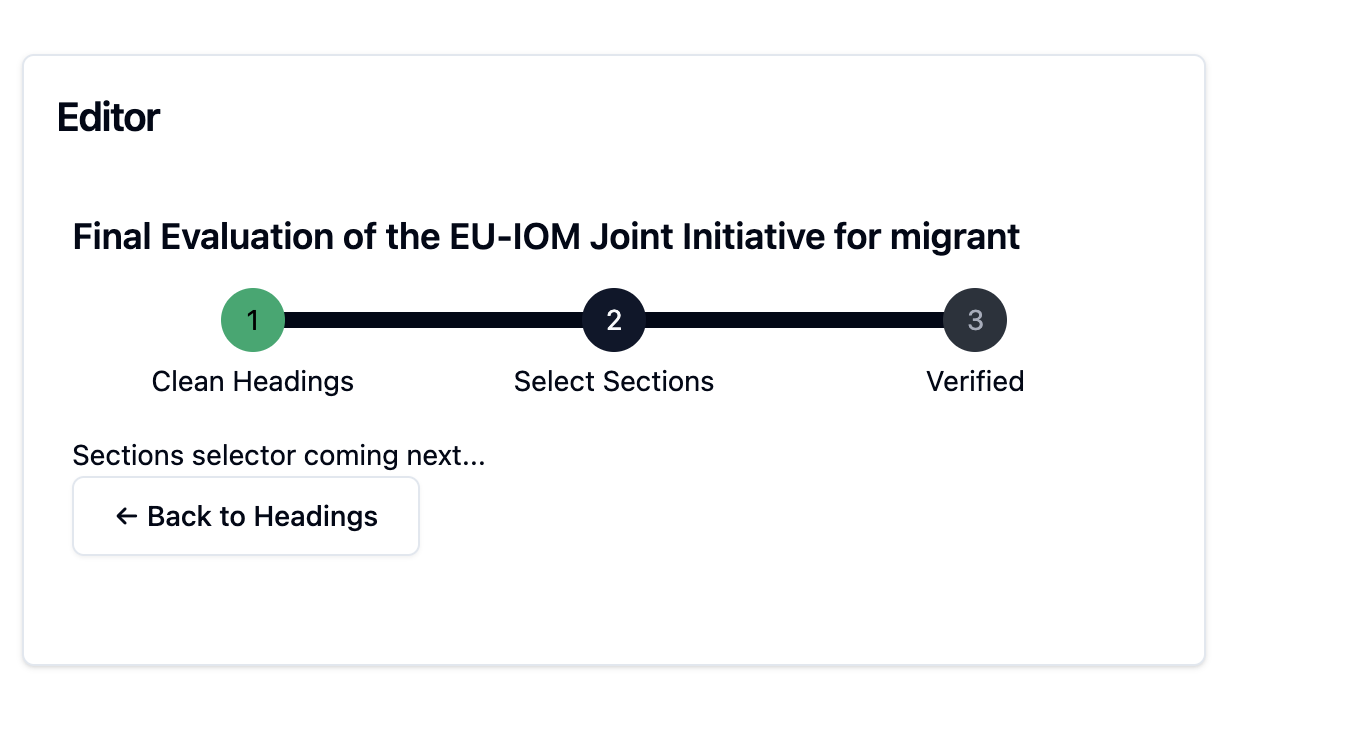

Ok our app looks great! The next step is to show somewhere the number of tokens of extracted sections dynamically when we select a heading. We can use helper functions from the "03_extract.ipynb" module for that purpose as well as the `n_tokens` function from "00_core.ipynb" module

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Nice progress! For dynamic token counting, we'll need:

1. An HTMX endpoint that calculates tokens for the selected headings
2. Checkboxes that trigger this endpoint on change
3. A display area showing the current token count

Quick question: should the token count update on every checkbox toggle (via `hx-trigger="change"`), or only when clicking a "Calculate" button?

I added a number of tokens text aside the button. We can move on

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Good! To make it dynamic, we need the checkboxes to call an endpoint that:
1. Receives the selected heading indices
2. Extracts the text for those headings
3. Calculates tokens with `n_tokens()`
4. Returns the updated count

Should the checkboxes use `hx-post` with `hx-trigger="change"` to update the token count on every toggle?

Yes, but we should pass all selected headings

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠🧠

Right. So each checkbox should trigger a form submission that sends all currently checked headings. We can do this with `hx-post` on the form with `hx-trigger="change from:input"`.

The endpoint would be something like `/report/{id}/token-count` and return just the updated `Span` with the token count.

Shall I show the endpoint signature, or do you want to try building it?

Show me

##### 🤖Reply🤖<!-- SOLVEIT_SEPARATOR_7f3a9b2c -->

🧠🧠🧠🧠🧠🧠🧠🧠🧠

```python
@rt('/report/{id}/token-count')
async def post(id:str, req:Request):
    form = await req.form()
    r = load_report(id, 'files/test')
    
    # Get selected heading indices
    selected = [int(k.split('_')[1]) for k in form.keys() if k.startswith('hdg_')]
    headings = get_headings(r.md_path)
    selected_hdgs = [headings[i] for i in selected]
    
    # Extract text and count tokens
    # TODO: use functions from 03_extract to get actual text
    text = ...  # extract text for selected_hdgs
    tokens = n_tokens(text)
    
    return Span(f"{tokens:,} tokens", id='token-count', cls='ml-4 text-sm'+TextT.muted)
```

For extracting the actual text from selected headings, what function from `03_extract.ipynb` do you have in mind?